In [1]:
%cd ..
%pwd  # should be "llm-adaptation"

C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation


'C:\\Users\\micha\\OneDrive - Univerzita Karlova\\research\\2024-LLM-DEECo\\llm-adaptation'

In [32]:
from pathlib import Path
import pandas as pd
import shutil
import subprocess
import sys
import json
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
from matplotlib.ticker import FixedFormatter
import numpy as np
import seaborn as sns

In [3]:
results_folder = Path("generated_adaptations/dragon")
# results_folder = Path("generated_adaptations/old/251015/dragon")
pd.options.display.float_format = "{:,.1f}".format

## Run experiments

In [4]:
prompt = "generated_adaptations/prompts_user/dragon_strategy.md"
variants = {
    "system": "system",
    "constraints": "all",
    "stats": "stats",
    "result": "result",
}
llms = {
    # "5nanolow": "gpt-5-nano-2025-08-07,reasoning_effort=low",
    "5nano": "gpt-5-nano-2025-08-07",
    # "5mini": "gpt-5-mini-2025-08-07",
    # "5": "gpt-5-2025-08-07",
}
repeats = 3
start = 1

In [5]:
# import generated_adaptations.generator as generator

In [6]:
for variant, mode in variants.items():
    for llm_name, llm in llms.items():
        for repeat in range(start, start + repeats):
            folder_name = f"{llm_name}_{repeat:02d}"
            print(f"\n{variant}/{folder_name}\n")
            folder = results_folder / variant / folder_name
            folder.mkdir(parents=True, exist_ok=True)
            shutil.copy(prompt, folder / "01_user.md")
            cmd  = [sys.executable, "generated_adaptations/generator.py", f"--folder={str(folder)}", f"--llm={llm}", f"--mode={mode}"]
            result = subprocess.run(cmd, capture_output=True, text=True)  # even capture_output=False does not stream in real-time, so we rather capture it and print it later
            print(result.stdout)
            print(result.stderr)
            # generator.main([f"--folder={str(folder)}"])  # this also does not show the real-time output


system/5nano_03

Loaded 2 messages from generated_adaptations\dragon\system\5nano_03.
Querying LLM with prompt 01_user.
TOKENS USED:
Input: 1066, Output: 8405 (reasoning: 7360)
Response time (seconds): 75.4

LLM response saved to '02_llm.md'.
Code block saved to 'generated_adaptations\dragon\system\5nano_03\code_02.py'.
Running tests (system): pytest generated_adaptations/tests -q --tb=short -rfExX --show-capture=no --color=no --example=dragon --adaptation_name=5nano_03/code_02 --variant=system --tests=system
Test exit code: 0
Running tests (all): pytest generated_adaptations/tests -q --tb=short -rfExX --show-capture=no --color=no --example=dragon --adaptation_name=5nano_03/code_02 --variant=system --tests=all
Test exit code: 1
Running simulation for 'generated_adaptations\dragon\system\5nano_03\code_02.py'.
  Run #1/3: python main.py dragon/configs/default.yaml generated_adaptations/configs/generated.yaml DSL/dragon.yaml --extra_config={"name": "system/5nano_03/code_02", "log_dir.app

## Results

In [7]:
# folders = list(results_folder.glob("*/*"))
folders = list(results_folder.glob("*/5nano_*"))
# folders = list(results_folder.glob("*/5nanolow*"))
# folders = [results_folder / "41mini"]
print([(f.parent.stem, f.stem) for f in folders])

[('constraints', '5nano_01'), ('constraints', '5nano_02'), ('constraints', '5nano_03'), ('constraints', '5nano_04'), ('constraints', '5nano_05'), ('result', '5nano_01'), ('result', '5nano_02'), ('result', '5nano_03'), ('result', '5nano_04'), ('result', '5nano_05'), ('stats', '5nano_01'), ('stats', '5nano_02'), ('stats', '5nano_03'), ('stats', '5nano_04'), ('stats', '5nano_05'), ('system', '5nano_01'), ('system', '5nano_02'), ('system', '5nano_03'), ('system', '5nano_04'), ('system', '5nano_05')]


In [8]:
summary = pd.DataFrame(columns=["llm", "params", "repeat"])

for folder in folders:
    llm, repeat = folder.stem.split("_")
    params = folder.parent.stem
    summary.loc[len(summary), ["llm", "params", "repeat"]] = [llm, params, repeat]

    for file in (folder / "results").glob("*.txt"):
        name = file.stem.removeprefix("code_")
        code = name.split("_")[0]
        if "_missing" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "missing"
            summary.loc[len(summary) - 1, code + "_result"] = "-"
        elif "_system_fail" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "fail"
        elif "_system_pass" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "pass"
        elif "_all_fail" in name:
            summary.loc[len(summary) - 1, code + "_user"] = "fail"
        elif "_all_pass" in name:
            summary.loc[len(summary) - 1, code + "_user"] = "pass"
        else:
            print(f"Unknown file: {file}")
    for file in (folder / "results").glob("*.json"):
        name = file.stem.removeprefix("code_")
        if "_simulation_result" in name:
            code = name.removesuffix("_simulation_result")
            results = json.load(open(file))
            # result = results["winrate"]
            result = results["steps"]
            if result is None:
                # result = "-"
                result = 30 + results.get("dragon_hp", 0) / 10  # penalize remaining HP
            summary.loc[len(summary) - 1, code + "_result"] = result
        else:
            print(f"Unknown file: {file}")

summary = summary.astype("object")
summary.fillna("", inplace=True)

C:\Users\micha\AppData\Local\Temp\ipykernel_18708\3393632664.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary.loc[len(summary) - 1, code + "_result"] = "-"
C:\Users\micha\AppData\Local\Temp\ipykernel_18708\3393632664.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary.loc[len(summary) - 1, code + "_result"] = "-"


In [9]:
summary.set_index(["llm", "params", "repeat"], inplace=True)

In [10]:
summary = summary.reindex(sorted(summary.columns), axis=1)

In [11]:
summary

02_result 02_system 02_user 04_result 04_system  \
llm   params      repeat                                                   
5nano constraints 01          10.7      pass    pass                       
                  02          33.2      pass    fail      14.3      pass   
                  03          33.2      fail    fail      33.2      pass   
                  04          33.2      pass    fail      10.7      pass   
                  05          10.7      pass    pass                       
      result      01          33.2      pass    fail      10.7      pass   
                  02          33.2      pass    fail      35.0      fail   
                  03          33.2      fail    fail      33.2      pass   
                  04          33.2      pass    fail      16.3      pass   
                  05          10.7      pass    pass                       
      stats       01          15.3      pass    pass      33.2      pass   
                  02          10.7      pass    pass                       
                  03          15.3      pass    pass      33.2      pass   
                  04          33.2      pass    fail      33.2      pass   
                  05          33.2      pass    fail      33.2      pass   
      system      01          33.2      pass    fail      33.2      pass   
                  02             -   missing              33.2      pass   
                  03          33.2      pass    fail      11.0      pass   
                  04          33.2      fail    fail      33.2      pass   
                  05          33.2      pass    fail      33.2      pass   

                         04_user 06_result 06_system 06_user 08_result  ...  \
llm   params      repeat                                                ...   
5nano constraints 01                                                    ...   
                  02        pass                                        ...   
                  03        fail      10.7      pass    pass            ...   
                  04        pass                                        ...   
                  05                                                    ...   
      result      01        pass                                        ...   
                  02        fail      35.0      fail    fail      35.0  ...   
                  03        fail      11.0      pass    fail      33.2  ...   
                  04        pass      15.7      pass    pass      17.3  ...   
                  05                                                    ...   
      stats       01        fail      15.3      pass    pass      33.2  ...   
                  02                                                    ...   
                  03        fail      14.0      pass    pass            ...   
                  04        fail      33.2      pass    fail      33.2  ...   
                  05        fail      33.2      fail    fail      12.7  ...   
      system      01        fail      10.7      pass    pass            ...   
                  02        fail      33.2      pass    fail      33.2  ...   
                  03        pass                                        ...   
                  04        fail      33.2      pass    fail      33.2  ...   
                  05        fail      33.2      pass    fail      10.7  ...   

                         14_user 16_result 16_system 16_user 18_result  \
llm   params      repeat                                                 
5nano constraints 01                                                     
                  02                                                     
                  03                                                     
                  04                                                     
                  05                                                     
      result      01                                                     
                  02 

### Plot

In [12]:
colors = {
    "5nano/constraints": "tab:blue",
    "5nano/system": "tab:green",
    "5nano/result": "tab:orange",
    "5nano/stats": "tab:red",
}

In [13]:
result_cols = [col for col in summary.columns if col.endswith("_result")]
# plot_data = summary[result_cols].replace({"-": 30, "": np.nan}).astype(float)
plot_data = summary[result_cols].replace({"-": 35, "": np.nan}).astype(float)
plot_data

C:\Users\micha\AppData\Local\Temp\ipykernel_18708\3704091001.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_data = summary[result_cols].replace({"-": 35, "": np.nan}).astype(float)


02_result  04_result  06_result  08_result  \
llm   params      repeat                                               
5nano constraints 01           10.7        NaN        NaN        NaN   
                  02           33.2       14.3        NaN        NaN   
                  03           33.2       33.2       10.7        NaN   
                  04           33.2       10.7        NaN        NaN   
                  05           10.7        NaN        NaN        NaN   
      result      01           33.2       10.7        NaN        NaN   
                  02           33.2       35.0       35.0       35.0   
                  03           33.2       33.2       11.0       33.2   
                  04           33.2       16.3       15.7       17.3   
                  05           10.7        NaN        NaN        NaN   
      stats       01           15.3       33.2       15.3       33.2   
                  02           10.7        NaN        NaN        NaN   
                  03           15.3       33.2       14.0        NaN   
                  04           33.2       33.2       33.2       33.2   
                  05           33.2       33.2       33.2       12.7   
      system      01           33.2       33.2       10.7        NaN   
                  02           35.0       33.2       33.2       33.2   
                  03           33.2       11.0        NaN        NaN   
                  04           33.2       33.2       33.2       33.2   
                  05           33.2       33.2       33.2       10.7   

                          10_result  12_result  14_result  16_result  \
llm   params      repeat                                               
5nano constraints 01            NaN        NaN        NaN        NaN   
                  02            NaN        NaN        NaN        NaN   
                  03            NaN        NaN        NaN        NaN   
                  04            NaN        NaN        NaN        NaN   
                  05            NaN        NaN        NaN        NaN   
      result      01            NaN        NaN        NaN        NaN   
                  02           19.7       16.7       33.2       33.2   
                  03           33.2       11.0       33.2       33.2   
                  04           35.0       17.3       33.2       33.2   
                  05            NaN        NaN        NaN        NaN   
      stats       01           15.3       15.0       13.5       14.3   
                  02            NaN        NaN        NaN        NaN   
                  03            NaN        NaN        NaN        NaN   
                  04           33.2       33.2       33.2       33.2   
                  05           11.0        NaN        NaN        NaN   
      system      01            NaN        NaN        NaN        NaN   
                  02           33.2       33.2       10.7        NaN   
                  03            NaN        NaN        NaN        NaN   
                  04           11.0        NaN        NaN        NaN   
                  05            NaN        NaN        NaN        NaN   

                          18_result  20_result  
llm   params      repeat                        
5nano constraints 01            NaN        NaN  
                  02            NaN        NaN  
                  03            NaN        NaN  
                  04            NaN        NaN  
                  05            NaN        NaN  
      result      01            NaN        NaN  
                  02           19.7       12.3  
                  03           10.7        NaN  
                  04           17.0       33.2  
                  05            NaN        NaN  
      stats       01            NaN        NaN  
                  02            NaN        NaN  
                  03            NaN        NaN  
                  04           33.2       33.2  
                  05            NaN        NaN  
      system      01   

In [17]:
stop_by_constraints = plot_data.copy()

def clear_after_pass(row):
    passed = False

    for col in row.index:
        if not passed:
            constraints_col = col.replace('_result', '_user')
            if summary.loc[row.name, constraints_col] == "pass":
                passed = True
        else:
            row[col] = np.nan
    return row

stop_by_constraints = stop_by_constraints.apply(clear_after_pass, axis=1)
plot_data = stop_by_constraints
stop_by_constraints

02_result  04_result  06_result  08_result  \
llm   params      repeat                                               
5nano constraints 01           10.7        NaN        NaN        NaN   
                  02           33.2       14.3        NaN        NaN   
                  03           33.2       33.2       10.7        NaN   
                  04           33.2       10.7        NaN        NaN   
                  05           10.7        NaN        NaN        NaN   
      result      01           33.2       10.7        NaN        NaN   
                  02           33.2       35.0       35.0       35.0   
                  03           33.2       33.2       11.0       33.2   
                  04           33.2       16.3        NaN        NaN   
                  05           10.7        NaN        NaN        NaN   
      stats       01           15.3        NaN        NaN        NaN   
                  02           10.7        NaN        NaN        NaN   
                  03           15.3        NaN        NaN        NaN   
                  04           33.2       33.2       33.2       33.2   
                  05           33.2       33.2       33.2       12.7   
      system      01           33.2       33.2       10.7        NaN   
                  02           35.0       33.2       33.2       33.2   
                  03           33.2       11.0        NaN        NaN   
                  04           33.2       33.2       33.2       33.2   
                  05           33.2       33.2       33.2       10.7   

                          10_result  12_result  14_result  16_result  \
llm   params      repeat                                               
5nano constraints 01            NaN        NaN        NaN        NaN   
                  02            NaN        NaN        NaN        NaN   
                  03            NaN        NaN        NaN        NaN   
                  04            NaN        NaN        NaN        NaN   
                  05            NaN        NaN        NaN        NaN   
      result      01            NaN        NaN        NaN        NaN   
                  02           19.7       16.7       33.2       33.2   
                  03           33.2       11.0       33.2       33.2   
                  04            NaN        NaN        NaN        NaN   
                  05            NaN        NaN        NaN        NaN   
      stats       01            NaN        NaN        NaN        NaN   
                  02            NaN        NaN        NaN        NaN   
                  03            NaN        NaN        NaN        NaN   
                  04           33.2       33.2       33.2       33.2   
                  05           11.0        NaN        NaN        NaN   
      system      01            NaN        NaN        NaN        NaN   
                  02           33.2       33.2       10.7        NaN   
                  03            NaN        NaN        NaN        NaN   
                  04           11.0        NaN        NaN        NaN   
                  05            NaN        NaN        NaN        NaN   

                          18_result  20_result  
llm   params      repeat                        
5nano constraints 01            NaN        NaN  
                  02            NaN        NaN  
                  03            NaN        NaN  
                  04            NaN        NaN  
                  05            NaN        NaN  
      result      01            NaN        NaN  
                  02           19.7       12.3  
                  03           10.7        NaN  
                  04            NaN        NaN  
                  05            NaN        NaN  
      stats       01            NaN        NaN  
                  02            NaN        NaN  
                  03            NaN        NaN  
                  04           33.2       33.2  
                  05            NaN        NaN  
      system      01   

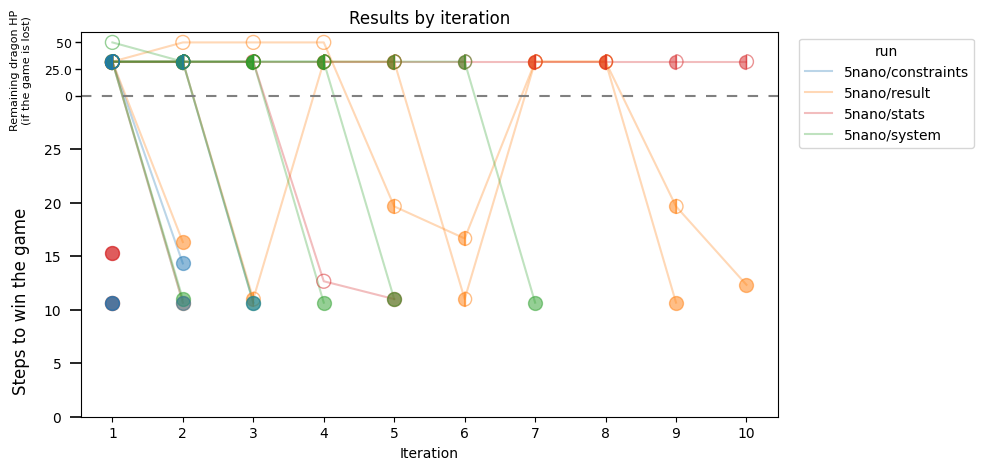

In [22]:
plot_df = plot_data.T.copy()  # index: result columns like `02_result`, columns: MultiIndex (llm, params, repeat)
orig_cols = plot_df.columns  # MultiIndex
labels = [f"{llm}/{params}/{repeat}" for llm, params, repeat in orig_cols]
x = list(range(1, len(plot_df.index) + 1))

fig, ax = plt.subplots(figsize=(9, 5))
for col, label in zip(orig_cols, labels):
    y = plot_df[col].values
    # draw the line for the run
    label_no_repeat = label.rsplit("/", 1)[0]
    color = colors[label_no_repeat]
    if label_no_repeat in ax.get_legend_handles_labels()[1]:
        label_no_repeat = None
    line, = ax.plot(x, y, '-', label=label_no_repeat, alpha=0.3, color=color)

    # collect indices by test status
    pass_idx, half_idx, fail_idx = [], [], []
    for i, result_col in enumerate(plot_df.index):  # e.g. '02_result'
        system_col = result_col.replace('_result', '_system')
        user_col = result_col.replace('_result', '_user')

        system = summary.loc[col, system_col]
        user = summary.loc[col, user_col]

        if system == "pass" and user == "pass":
            pass_idx.append(i)
        elif system == "pass":
            half_idx.append(i)
        else:
            fail_idx.append(i)

    # overplot markers (use same color as the line)
    scatter_kwargs = {
        "zorder": 5 if "constraints" in label else 3,
        "s": 100, "alpha": 0.5
    }
    if pass_idx:
        ax.scatter([x[i] for i in pass_idx], [y[i] for i in pass_idx], marker='o', color=color, **scatter_kwargs)
    if half_idx:
        ax.scatter([x[i] for i in half_idx], [y[i] for i in half_idx], marker=MarkerStyle("o", fillstyle="left"), color=color, **scatter_kwargs)
        ax.scatter([x[i] for i in half_idx], [y[i] for i in half_idx], marker=MarkerStyle("o", fillstyle="right"), color="none", edgecolors=color, **scatter_kwargs)
    if fail_idx:
        ax.scatter([x[i] for i in fail_idx], [y[i] for i in fail_idx], marker='o', color=color, facecolors='none', **scatter_kwargs)

# finalize axes
ax.set_xticks(x)
ax.set_xticklabels(x)  # iterations 1,2,3,...
ax.set_xlabel("Iteration")

# y axis
xlim = ax.get_xlim()
ax.plot(xlim, [30, 30], linestyle=(0, (5, 5)), c='gray')
ax.set_xlim(xlim)
major_ticks = list(range(0, 30, 5))
minor_ticks = [30, 32.5, 35]
ax.set_ylim(0, 36)
ax.set_yticks(major_ticks)
ax.set_yticks(minor_ticks, minor=True)
ax.set_yticklabels([str(t) for t in major_ticks])
ax.yaxis.set_minor_formatter(FixedFormatter([str((t - 30) * 10) for t in minor_ticks]))
ax.tick_params(axis='y', which='major', length=8, width=1.2, labelsize=10, pad=6)
ax.tick_params(axis='y', which='minor', length=4, width=1.0, labelsize=9, pad=2, labelbottom=True)
ax.text(-0.3, 0.3, "Steps to win the game", transform=ax.get_xaxis_transform(), rotation=90, ha='center', va='center', fontsize=12)
ax.text(-0.3, 0.9, "Remaining dragon HP\n(if the game is lost)", transform=ax.get_xaxis_transform(), rotation=90, ha='center', va='center', fontsize=8)
# ax.set_ylabel("Result (steps)")

ax.set_title("Results by iteration")
ax.legend(title="run", bbox_to_anchor=(1.02, 1), loc="upper left")
# plt.tight_layout()
plt.show()

### Iteration counts

In [35]:
iterations = plot_data.apply(lambda row: row.count(), axis=1)
iterations = pd.DataFrame(iterations).rename(columns={0: "iterations"})
iterations

iterations
llm   params      repeat            
5nano constraints 01               1
                  02               2
                  03               3
                  04               2
                  05               1
      result      01               2
                  02              10
                  03               9
                  04               2
                  05               1
      stats       01               1
                  02               1
                  03               1
                  04              10
                  05               5
      system      01               3
                  02               7
                  03               2
                  04               5
                  05               4

<Axes: xlabel='iterations', ylabel='params'>

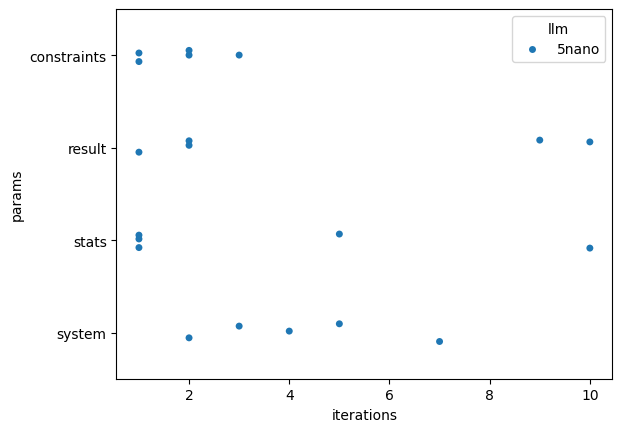

In [36]:
sns.stripplot(x="iterations", y="params", hue="llm", data=iterations.reset_index(), dodge=True)